In [15]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path.cwd()
(BASE_DIR / "outputs").mkdir(parents=True, exist_ok=True)
DB_PATH = BASE_DIR / "database" / "subway.db"

conn = sqlite3.connect(DB_PATH)

print("Database connected.")

Database connected.


In [16]:
query_line = """
SELECT
    line,
    SUM(
        before_06 +
        hour_06_07 +
        hour_07_08 +
        hour_08_09 +
        hour_09_10 +
        hour_10_11 +
        hour_11_12 +
        hour_12_13 +
        hour_13_14 +
        hour_14_15 +
        hour_15_16 +
        hour_16_17 +
        hour_17_18 +
        hour_18_19 +
        hour_19_20 +
        hour_20_21 +
        hour_21_22 +
        hour_22_23 +
        hour_23_24 +
        after_24
    ) AS total_passengers
FROM subway_ridership
GROUP BY line
ORDER BY total_passengers DESC;
"""

line_df = pd.read_sql_query(query_line, conn)

line_df

,line,total_passengers
0,2호선,1013126430
1,5호선,471559184
2,7호선,414146082
3,3호선,382710330
4,4호선,381041437
5,6호선,244962263
6,1호선,186645972
7,8호선,147471907


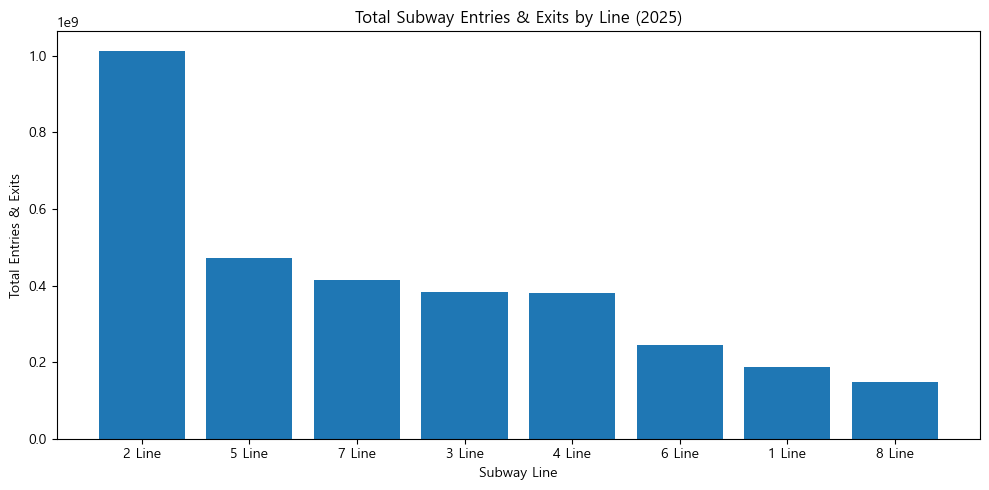

In [17]:
plot_df = line_df.copy()
plot_df["line"] = plot_df["line"].str.replace("호선", "", regex=False) + " Line"

plt.figure(figsize=(10, 5))

plt.bar(
    plot_df["line"],
    plot_df["total_passengers"]
)

plt.title("Total Subway Entries & Exits by Line (2025)")
plt.xlabel("Subway Line")
plt.ylabel("Total Entries & Exits")

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "passengers_by_line.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
query_time = """
SELECT
    SUM(before_06) AS before_06,
    SUM(hour_06_07) AS hour_06_07,
    SUM(hour_07_08) AS hour_07_08,
    SUM(hour_08_09) AS hour_08_09,
    SUM(hour_09_10) AS hour_09_10,
    SUM(hour_10_11) AS hour_10_11,
    SUM(hour_11_12) AS hour_11_12,
    SUM(hour_12_13) AS hour_12_13,
    SUM(hour_13_14) AS hour_13_14,
    SUM(hour_14_15) AS hour_14_15,
    SUM(hour_15_16) AS hour_15_16,
    SUM(hour_16_17) AS hour_16_17,
    SUM(hour_17_18) AS hour_17_18,
    SUM(hour_18_19) AS hour_18_19,
    SUM(hour_19_20) AS hour_19_20,
    SUM(hour_20_21) AS hour_20_21,
    SUM(hour_21_22) AS hour_21_22,
    SUM(hour_22_23) AS hour_22_23,
    SUM(hour_23_24) AS hour_23_24,
    SUM(after_24) AS after_24
FROM subway_ridership;
"""

time_df = pd.read_sql_query(query_time, conn)

time_df

,before_06,hour_06_07,hour_07_08,hour_08_09,hour_09_10,hour_10_11,hour_11_12,hour_12_13,hour_13_14,hour_14_15,hour_15_16,hour_16_17,hour_17_18,hour_18_19,hour_19_20,hour_20_21,hour_21_22,hour_22_23,hour_23_24,after_24
0,26610434,76241676,186121876,312295246,210072337,149614879,145818622,155306046,164561115,164144635,180554020,207520296,263633103,326964216,205137931,147661568,134525198,111294892,57986079,15599436


In [19]:
time_long = time_df.T.reset_index()

time_long.columns = ["time", "total_passengers"]

time_long

,time,total_passengers
0,before_06,26610434
1,hour_06_07,76241676
2,hour_07_08,186121876
3,hour_08_09,312295246
4,hour_09_10,210072337
5,hour_10_11,149614879
6,hour_11_12,145818622
7,hour_12_13,155306046
8,hour_13_14,164561115
9,hour_14_15,164144635


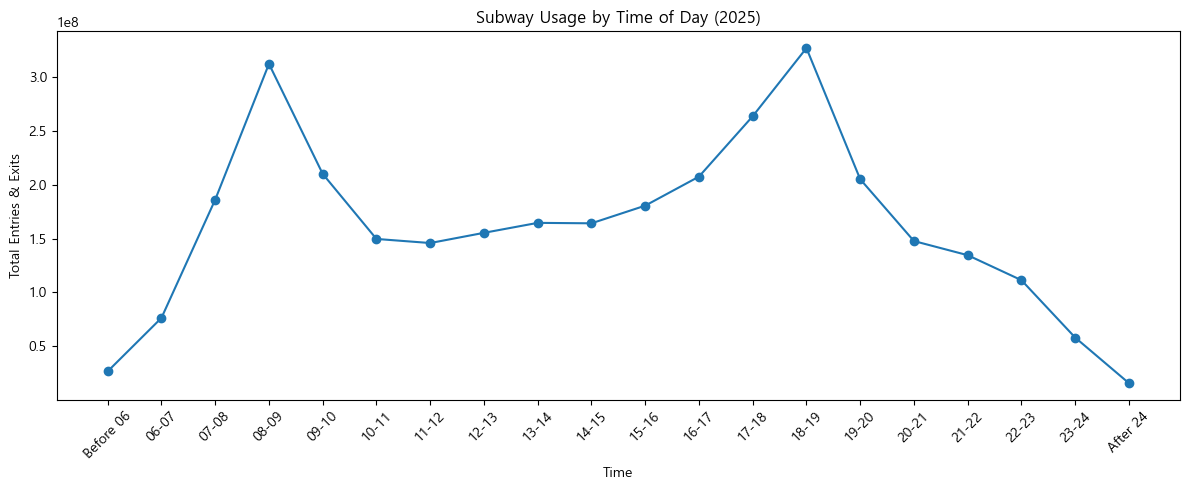

In [20]:
# 그래프에 사용할 시간대 이름
time_labels = [
    "Before 06",
    "06-07",
    "07-08",
    "08-09",
    "09-10",
    "10-11",
    "11-12",
    "12-13",
    "13-14",
    "14-15",
    "15-16",
    "16-17",
    "17-18",
    "18-19",
    "19-20",
    "20-21",
    "21-22",
    "22-23",
    "23-24",
    "After 24"
]

time_long["time"] = time_labels

plt.figure(figsize=(12, 5))

plt.plot(
    time_long["time"],
    time_long["total_passengers"],
    marker="o"
)

plt.title("Subway Usage by Time of Day (2025)")
plt.xlabel("Time")
plt.ylabel("Total Entries & Exits")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "passengers_by_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
query_weekday = """
SELECT
    CASE
        WHEN strftime('%w', date) IN ('0', '6') THEN 'Weekend'
        ELSE 'Weekday'
    END AS day_type,

    COUNT(DISTINCT date) AS number_of_days,

    SUM(
        before_06 +
        hour_06_07 +
        hour_07_08 +
        hour_08_09 +
        hour_09_10 +
        hour_10_11 +
        hour_11_12 +
        hour_12_13 +
        hour_13_14 +
        hour_14_15 +
        hour_15_16 +
        hour_16_17 +
        hour_17_18 +
        hour_18_19 +
        hour_19_20 +
        hour_20_21 +
        hour_21_22 +
        hour_22_23 +
        hour_23_24 +
        after_24
    ) AS total_passengers

FROM subway_ridership

GROUP BY day_type;
"""

weekday_df = pd.read_sql_query(query_weekday, conn)

weekday_df

,day_type,number_of_days,total_passengers
0,Weekday,261,2559697692
1,Weekend,104,681965913


In [22]:
weekday_df["avg_daily_passengers"] = (
    weekday_df["total_passengers"]
    / weekday_df["number_of_days"]
)

weekday_df

,day_type,number_of_days,total_passengers,avg_daily_passengers
0,Weekday,261,2559697692,9.807271e+06
1,Weekend,104,681965913,6.557365e+06


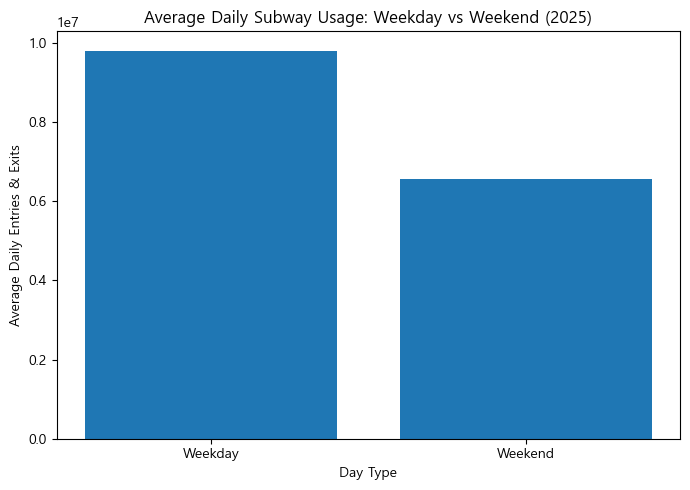

In [23]:
plt.figure(figsize=(7, 5))

plt.bar(
    weekday_df["day_type"],
    weekday_df["avg_daily_passengers"]
)

plt.title("Average Daily Subway Usage: Weekday vs Weekend (2025)")
plt.xlabel("Day Type")
plt.ylabel("Average Daily Entries & Exits")

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "weekday_vs_weekend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
query_boarding = """
SELECT
    station_name,

    SUM(
        CASE WHEN direction = '승차' THEN
            before_06 +
            hour_06_07 +
            hour_07_08 +
            hour_08_09 +
            hour_09_10 +
            hour_10_11 +
            hour_11_12 +
            hour_12_13 +
            hour_13_14 +
            hour_14_15 +
            hour_15_16 +
            hour_16_17 +
            hour_17_18 +
            hour_18_19 +
            hour_19_20 +
            hour_20_21 +
            hour_21_22 +
            hour_22_23 +
            hour_23_24 +
            after_24
        ELSE 0 END
    ) AS boardings,

    SUM(
        CASE WHEN direction = '하차' THEN
            before_06 +
            hour_06_07 +
            hour_07_08 +
            hour_08_09 +
            hour_09_10 +
            hour_10_11 +
            hour_11_12 +
            hour_12_13 +
            hour_13_14 +
            hour_14_15 +
            hour_15_16 +
            hour_16_17 +
            hour_17_18 +
            hour_18_19 +
            hour_19_20 +
            hour_20_21 +
            hour_21_22 +
            hour_22_23 +
            hour_23_24 +
            after_24
        ELSE 0 END
    ) AS alightings

FROM subway_ridership

GROUP BY station_name;
"""

boarding_df = pd.read_sql_query(query_boarding, conn)

boarding_df["difference"] = (
    boarding_df["boardings"] - boarding_df["alightings"]
)

boarding_df["abs_difference"] = boarding_df["difference"].abs()

boarding_top10 = (
    boarding_df
    .sort_values("abs_difference", ascending=False)
    .head(10)
)

boarding_top10

,station_name,boardings,alightings,difference,abs_difference
119,서울역,30609021,33031245,-2422224,2422224
123,선릉,19061924,16750395,2311529,2311529
236,홍대입구,26891124,29059593,-2168469,2168469
167,역삼,16410765,18478546,-2067781,2067781
16,고속터미널,25142496,23107635,2034861,2034861
33,김포공항,4641860,2924462,1717398,1717398
124,성수,17983858,19424390,-1440532,1440532
43,노원,14627995,15866540,-1238545,1238545
233,합정,16506835,17573980,-1067145,1067145
79,명동,13287503,14190447,-902944,902944


In [25]:
query_monthly = """
SELECT
    strftime('%m', date) AS month,

    SUM(
        before_06 +
        hour_06_07 +
        hour_07_08 +
        hour_08_09 +
        hour_09_10 +
        hour_10_11 +
        hour_11_12 +
        hour_12_13 +
        hour_13_14 +
        hour_14_15 +
        hour_15_16 +
        hour_16_17 +
        hour_17_18 +
        hour_18_19 +
        hour_19_20 +
        hour_20_21 +
        hour_21_22 +
        hour_22_23 +
        hour_23_24 +
        after_24
    ) AS total_passengers

FROM subway_ridership

GROUP BY month
ORDER BY month;
"""

monthly_df = pd.read_sql_query(query_monthly, conn)

monthly_df

,month,total_passengers
0,01,239073217
1,02,246342481
2,03,281129083
3,04,283803306
4,05,279891596
5,06,263073620
6,07,275510816
7,08,259418351
8,09,280673268
9,10,260614295


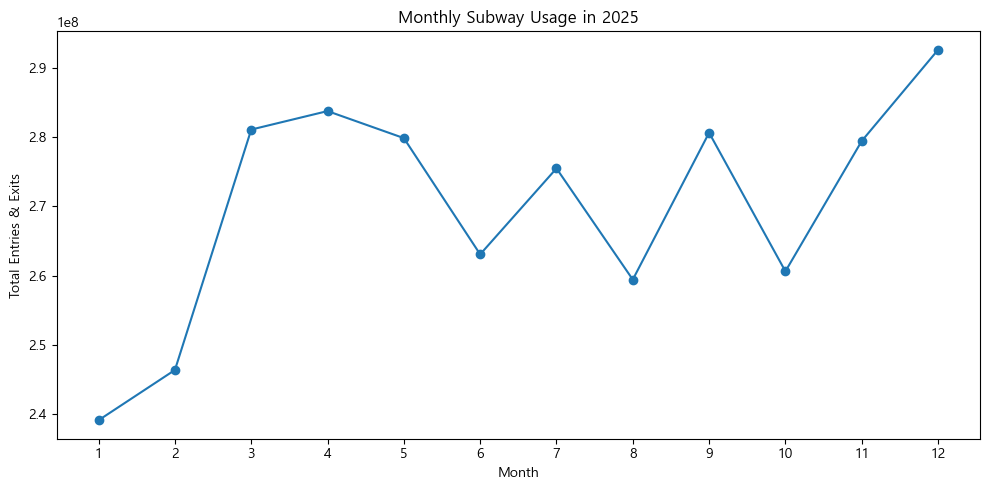

In [26]:
# 그래프용 월 이름
monthly_plot = monthly_df.copy()
monthly_plot["month"] = monthly_plot["month"].astype(int)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_plot["month"],
    monthly_plot["total_passengers"],
    marker="o"
)

plt.title("Monthly Subway Usage in 2025")
plt.xlabel("Month")
plt.ylabel("Total Entries & Exits")

plt.xticks(range(1, 13))
plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "monthly_passengers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

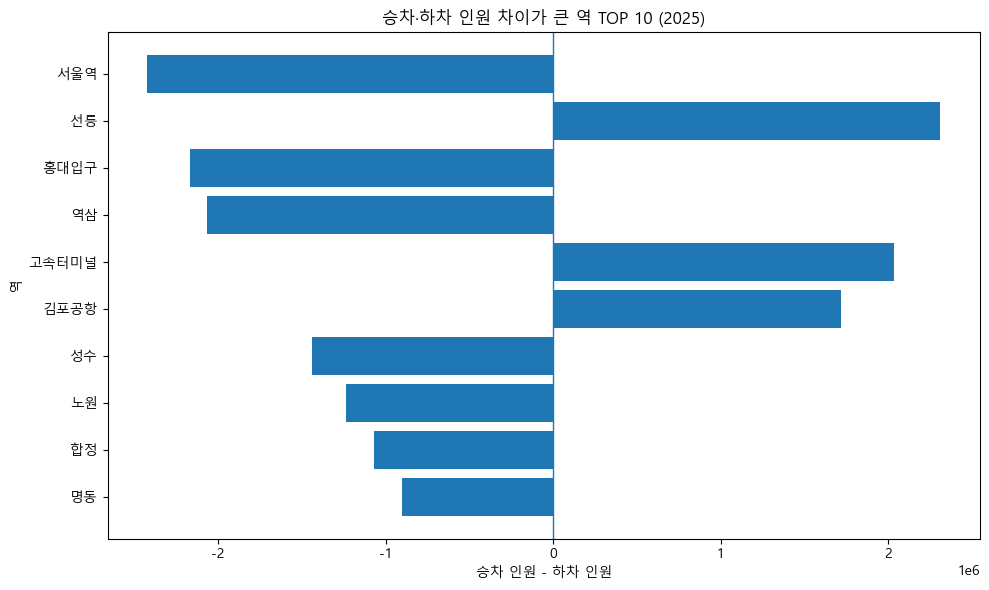

In [27]:
import matplotlib.pyplot as plt

# Windows 한글 폰트
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 그래프용 데이터
boarding_plot = boarding_top10.sort_values(
    "abs_difference",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    boarding_plot["station_name"],
    boarding_plot["difference"]
)

plt.axvline(0, linewidth=1)

plt.title("승차·하차 인원 차이가 큰 역 TOP 10 (2025)")
plt.xlabel("승차 인원 - 하차 인원")
plt.ylabel("역")

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "boarding_alighting_difference.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()